# In-Class Activity 4-23: Feature Reduction, Model Tuning, and Stacking
**Tyler Wolf Williams**  
Starting from 377 polynomial-interaction features, reducing to ≤20, tuning two models with Optuna, and stacking with a meta-learner.

In [2]:
# pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   --------------------------------------- 555.9/555.9 kB 11.8 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
# Core imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import PolynomialFeatures

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading and Preprocessing

In [ ]:
# Load data
adult = pd.read_csv('../4-21/adult.csv')

# Binary-encode target
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Drop fnlwgt (census weight, not predictive)
adult.drop(columns=['fnlwgt'], inplace=True)

# Binary-encode gender
adult['gender'] = adult['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Replace '?' with NaN then impute
adult.replace('?', np.nan, inplace=True)
for col in adult.columns:
    if adult[col].dtype == 'object':
        adult[col] = adult[col].fillna('unknown')
    else:
        adult[col] = adult[col].fillna(adult[col].median())

print('Dataset shape:', adult.shape)
adult.head()

Dataset shape: (48842, 14)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


## 2. Feature Engineering

In [5]:
X = adult.drop('income', axis=1)
y = adult['income']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

# --- Rare-label encode ---
rare_enc = RareLabelEncoder(tol=0.01, variables=cat_cols)
X_train_fe = rare_enc.fit_transform(X_train_raw)
X_test_fe  = rare_enc.transform(X_test_raw)

# --- Frequency encode ---
freq_enc = CountFrequencyEncoder(variables=cat_cols, encoding_method='frequency')
X_train_fe = freq_enc.fit_transform(X_train_fe)
X_test_fe  = freq_enc.transform(X_test_fe)

# --- Equal-frequency discretise (skip binary cols & capital cols) ---
disc_vars = [c for c in num_cols if c not in ['gender', 'capital-gain', 'capital-loss']]
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)
X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe  = disc.transform(X_test_fe)

# --- Drop constant features ---
const_drop = DropConstantFeatures()
X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe  = const_drop.transform(X_test_fe)

print('Feature-engineered shape:', X_train_fe.shape)

# --- Degree-3 interaction features ---
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_train_poly = pd.DataFrame(
    poly.fit_transform(X_train_fe),
    columns=poly.get_feature_names_out(X_train_fe.columns),
    index=X_train_fe.index
)
X_test_poly = pd.DataFrame(
    poly.transform(X_test_fe),
    columns=poly.get_feature_names_out(X_train_fe.columns),
    index=X_test_fe.index
)

print('Polynomial feature shape:', X_train_poly.shape)

Feature-engineered shape: (39073, 13)
Polynomial feature shape: (39073, 377)


## 3. Feature Reduction: 377 → ≤20 Features
Strategy: fit quick RF and XGBoost baselines on the 377-column set, compute both built-in feature importance and permutation importance, average the ranks across both models and both methods, and keep the top 15.

In [6]:
# Class-imbalance weight for XGBoost
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Fit quick baseline models on full 377-feature set ---
rf_full = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    max_features='sqrt', random_state=42, n_jobs=-1
)
xgb_full = XGBClassifier(
    n_estimators=100, scale_pos_weight=spw,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

rf_full.fit(X_train_poly, y_train)
xgb_full.fit(X_train_poly, y_train)

# Baseline scores on 377 features (test set)
print('RF  (377 features) test balanced accuracy:',
      balanced_accuracy_score(y_test, rf_full.predict(X_test_poly)))
print('XGB (377 features) test balanced accuracy:',
      balanced_accuracy_score(y_test, xgb_full.predict(X_test_poly)))

RF  (377 features) test balanced accuracy: 0.7999303313898185
XGB (377 features) test balanced accuracy: 0.8346195606940567


In [7]:
# Compute permutation importance on test set for both models
rf_perm  = permutation_importance(rf_full,  X_test_poly, y_test, n_repeats=5, random_state=42, n_jobs=-1)
xgb_perm = permutation_importance(xgb_full, X_test_poly, y_test, n_repeats=5, random_state=42, n_jobs=-1)

# Build ranking DataFrames
feat_names = X_train_poly.columns.tolist()

rf_df = pd.DataFrame({
    'feature': feat_names,
    'rf_fi':   rf_full.feature_importances_,
    'rf_perm': rf_perm.importances_mean
})

xgb_df = pd.DataFrame({
    'feature':  feat_names,
    'xgb_fi':   xgb_full.feature_importances_,
    'xgb_perm': xgb_perm.importances_mean
})

combined = rf_df.merge(xgb_df, on='feature')

# Rank each method (1 = most important)
for col in ['rf_fi', 'rf_perm', 'xgb_fi', 'xgb_perm']:
    combined[f'rank_{col}'] = combined[col].rank(ascending=False)

combined['avg_rank'] = combined[['rank_rf_fi', 'rank_rf_perm', 'rank_xgb_fi', 'rank_xgb_perm']].mean(axis=1)
combined = combined.sort_values('avg_rank')

print('Top 20 features by averaged rank:')
print(combined[['feature', 'rf_fi', 'xgb_fi', 'rf_perm', 'xgb_perm', 'avg_rank']].head(20).to_string(index=False))

Top 20 features by averaged rank:
                                    feature    rf_fi   xgb_fi  rf_perm  xgb_perm  avg_rank
                               capital-gain 0.006203 0.021948 0.000491  0.020534    15.375
                  relationship capital-gain 0.004050 0.005811 0.000430  0.002559    29.625
                marital-status capital-gain 0.002765 0.004497 0.000491  0.004688    39.375
educational-num relationship hours-per-week 0.006276 0.010310 0.000594  0.000061    41.750
                  occupation native-country 0.002615 0.003579 0.000614  0.001024    45.375
  educational-num marital-status occupation 0.010691 0.001252 0.001146  0.000246    53.875
                          occupation gender 0.002011 0.007533 0.000409  0.000553    59.000
           relationship gender capital-gain 0.001816 0.003883 0.000512  0.000594    62.750
                 educational-num occupation 0.003927 0.017588 0.000020  0.002743    64.625
     marital-status occupation relationship 0.005379 0.0

SHAP mean absolute importance (top 20):
marital-status                              1.030523
capital-gain                                0.311975
age educational-num hours-per-week          0.222350
marital-status occupation                   0.180271
age occupation native-country               0.131687
occupation                                  0.125528
educational-num occupation                  0.123886
age education hours-per-week                0.110211
age educational-num                         0.110024
age relationship hours-per-week             0.102234
age educational-num occupation              0.099840
age education race                          0.095089
capital-loss                                0.094425
marital-status capital-gain                 0.088688
age educational-num race                    0.070278
age education occupation                    0.068106
age marital-status hours-per-week           0.067129
age relationship race                       0.061631
marita

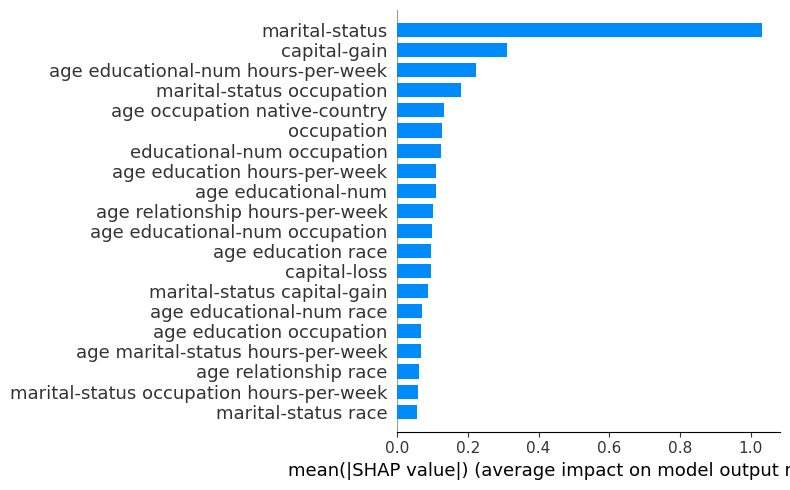

In [8]:
# SHAP on XGBoost to validate and visualise top features
explainer = shap.TreeExplainer(xgb_full)
# Use a sample to keep it fast
sample_idx = X_test_poly.sample(500, random_state=42).index
shap_vals = explainer.shap_values(X_test_poly.loc[sample_idx])

print('SHAP mean absolute importance (top 20):')
shap_imp = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feat_names
).sort_values(ascending=False)
print(shap_imp.head(20).to_string())

shap.summary_plot(shap_vals, X_test_poly.loc[sample_idx], plot_type='bar',
                  max_display=20, plot_size=(8, 5))

In [9]:
# Add SHAP rank to the combined DataFrame and re-average
shap_df = pd.DataFrame({'feature': feat_names, 'shap': shap_imp.values})
combined = combined.merge(shap_df, on='feature')
combined['rank_shap'] = combined['shap'].rank(ascending=False)
combined['avg_rank_final'] = combined[[
    'rank_rf_fi', 'rank_rf_perm', 'rank_xgb_fi', 'rank_xgb_perm', 'rank_shap'
]].mean(axis=1)
combined = combined.sort_values('avg_rank_final')

# Select top 15 features
TOP_N = 15
selected_features = combined['feature'].head(TOP_N).tolist()

print(f'Selected {TOP_N} features:')
for f in selected_features:
    print(' -', f)

Selected 15 features:
 - capital-gain
 - relationship capital-gain
 - marital-status capital-gain
 - occupation native-country
 - occupation gender
 - educational-num occupation
 - capital-loss
 - marital-status
 - age occupation
 - marital-status capital-loss
 - educational-num native-country
 - capital-gain native-country
 - age educational-num
 - educational-num relationship hours-per-week
 - educational-num marital-status occupation


In [10]:
# Build reduced datasets
X_train_red = X_train_poly[selected_features]
X_test_red  = X_test_poly[selected_features]

# Quick check: baseline RF and XGB on reduced feature set (default params)
rf_base_red = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
xgb_base_red = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1)

rf_cv_red  = cross_val_score(rf_base_red,  X_train_red, y_train, cv=skf, scoring='balanced_accuracy')
xgb_cv_red = cross_val_score(xgb_base_red, X_train_red, y_train, cv=skf, scoring='balanced_accuracy')

rf_base_red.fit(X_train_red, y_train)
xgb_base_red.fit(X_train_red, y_train)

print(f'RF  baseline (15 features) CV:   {rf_cv_red.mean():.4f} ± {rf_cv_red.std():.4f}')
print(f'XGB baseline (15 features) CV:   {xgb_cv_red.mean():.4f} ± {xgb_cv_red.std():.4f}')
print(f'RF  baseline (15 features) test: {balanced_accuracy_score(y_test, rf_base_red.predict(X_test_red)):.4f}')
print(f'XGB baseline (15 features) test: {balanced_accuracy_score(y_test, xgb_base_red.predict(X_test_red)):.4f}')

RF  baseline (15 features) CV:   0.8095 ± 0.0049
XGB baseline (15 features) CV:   0.8318 ± 0.0044
RF  baseline (15 features) test: 0.8107
XGB baseline (15 features) test: 0.8296


## 4. Model 1 — XGBoost Tuned with Optuna
XGBoost builds trees greedily in a depth-first manner with second-order Taylor approximations of the loss. It uses pre-sorted or histogram-based split finding.

In [11]:
def xgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 800),
        'max_depth':          trial.suggest_int('max_depth', 3, 8),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':   spw,
        'eval_metric':        'logloss',
        'random_state':       42,
        'n_jobs':             -1
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_red, y_train, cv=skf,
                             scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=40, show_progress_bar=True)

print('Best XGB CV balanced accuracy:', study_xgb.best_value)
print('Best XGB params:', study_xgb.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Best XGB CV balanced accuracy: 0.8339758252781653
Best XGB params: {'n_estimators': 601, 'max_depth': 7, 'learning_rate': 0.014306365273096887, 'subsample': 0.7770758708850692, 'colsample_bytree': 0.6537216739378713, 'min_child_weight': 8, 'reg_alpha': 0.15378454667449434, 'reg_lambda': 0.00020087580195160833}


In [12]:
# Fit tuned XGBoost on full training set
xgb_tuned = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train_red, y_train)
xgb_tuned_test_score = balanced_accuracy_score(y_test, xgb_tuned.predict(X_test_red))
print(f'XGB tuned test balanced accuracy: {xgb_tuned_test_score:.4f}')

XGB tuned test balanced accuracy: 0.8298


## 5. Model 2 — LightGBM Tuned with Optuna
LightGBM differs from XGBoost in two key ways: it grows trees **leaf-wise** (best-first) rather than level-wise, and it uses **gradient-based one-side sampling (GOSS)** and **exclusive feature bundling (EFB)** to reduce data/feature counts. This makes it faster on large datasets and often gives better accuracy with fewer boosting rounds.

In [13]:
def lgbm_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 800),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight':       'balanced',
        'random_state':       42,
        'n_jobs':             -1,
        'verbose':            -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_red, y_train, cv=skf,
                             scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(lgbm_objective, n_trials=40, show_progress_bar=True)

print('Best LGBM CV balanced accuracy:', study_lgbm.best_value)
print('Best LGBM params:', study_lgbm.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Best LGBM CV balanced accuracy: 0.8342948110703092
Best LGBM params: {'n_estimators': 572, 'num_leaves': 53, 'learning_rate': 0.014294651571088399, 'subsample': 0.800120582375693, 'colsample_bytree': 0.7363514455960307, 'min_child_samples': 42, 'reg_alpha': 0.000745719801647526, 'reg_lambda': 0.0022295348153570475}


In [14]:
# Fit tuned LightGBM on full training set
lgbm_tuned = LGBMClassifier(
    **study_lgbm.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_tuned.fit(X_train_red, y_train)
lgbm_tuned_test_score = balanced_accuracy_score(y_test, lgbm_tuned.predict(X_test_red))
print(f'LGBM tuned test balanced accuracy: {lgbm_tuned_test_score:.4f}')

LGBM tuned test balanced accuracy: 0.8319


## 6. Stacking: OOF Meta-Learner
Both tuned base models generate out-of-fold probability predictions on the training set. A Logistic Regression meta-learner is trained on those OOF predictions, then base models are retrained on the full training set and used to generate test-set features for the meta-learner.

In [15]:
# --- OOF Stacking ---

# Re-create best param dicts (strip keys added at fit time)
xgb_best_params = dict(study_xgb.best_params)
lgbm_best_params = dict(study_lgbm.best_params)

skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_oof  = np.zeros(len(X_train_red))
lgbm_oof = np.zeros(len(X_train_red))

for fold, (tr_idx, val_idx) in enumerate(skf_stack.split(X_train_red, y_train)):
    X_tr,  X_val  = X_train_red.iloc[tr_idx],  X_train_red.iloc[val_idx]
    y_tr          = y_train.iloc[tr_idx]

    # XGBoost fold
    m_xgb = XGBClassifier(
        **xgb_best_params,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    m_xgb.fit(X_tr, y_tr)
    xgb_oof[val_idx] = m_xgb.predict_proba(X_val)[:, 1]

    # LightGBM fold
    m_lgbm = LGBMClassifier(
        **lgbm_best_params,
        class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    )
    m_lgbm.fit(X_tr, y_tr)
    lgbm_oof[val_idx] = m_lgbm.predict_proba(X_val)[:, 1]

    print(f'  Fold {fold+1} done')

# Train meta-learner on OOF predictions
X_meta_train = np.column_stack([xgb_oof, lgbm_oof])
meta = LogisticRegression(random_state=42, max_iter=500)
meta.fit(X_meta_train, y_train)

print('OOF stacking complete. Meta-learner coefficients:', meta.coef_)

  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done
OOF stacking complete. Meta-learner coefficients: [[3.07178544 3.17013343]]


In [16]:
# Retrain base models on full training data
xgb_final = XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_final.fit(X_train_red, y_train)

lgbm_final = LGBMClassifier(
    **lgbm_best_params,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_final.fit(X_train_red, y_train)

# Generate test meta-features and predict
xgb_test_proba  = xgb_final.predict_proba(X_test_red)[:, 1]
lgbm_test_proba = lgbm_final.predict_proba(X_test_red)[:, 1]

X_meta_test = np.column_stack([xgb_test_proba, lgbm_test_proba])
stacked_preds = meta.predict(X_meta_test)

stacked_score = balanced_accuracy_score(y_test, stacked_preds)
print(f'Stacked model test balanced accuracy: {stacked_score:.4f}')

Stacked model test balanced accuracy: 0.8072


## 7. Summary Comparison

In [17]:
results = pd.DataFrame({
    'Model': [
        'RF  baseline (377 features)',
        'XGB baseline (377 features)',
        'RF  baseline (15 features)',
        'XGB baseline (15 features)',
        'XGB tuned    (15 features)',
        'LGBM tuned   (15 features)',
        'Stacked XGB+LGBM (15 features)'
    ],
    'Test Balanced Accuracy': [
        balanced_accuracy_score(y_test, rf_full.predict(X_test_poly)),
        balanced_accuracy_score(y_test, xgb_full.predict(X_test_poly)),
        balanced_accuracy_score(y_test, rf_base_red.predict(X_test_red)),
        balanced_accuracy_score(y_test, xgb_base_red.predict(X_test_red)),
        xgb_tuned_test_score,
        lgbm_tuned_test_score,
        stacked_score
    ]
})
results['Test Balanced Accuracy'] = results['Test Balanced Accuracy'].round(4)
print(results.to_string(index=False))

                         Model  Test Balanced Accuracy
   RF  baseline (377 features)                  0.7999
   XGB baseline (377 features)                  0.8346
    RF  baseline (15 features)                  0.8107
    XGB baseline (15 features)                  0.8296
    XGB tuned    (15 features)                  0.8298
    LGBM tuned   (15 features)                  0.8319
Stacked XGB+LGBM (15 features)                  0.8072


In [18]:
# Feature importance of both tuned models on reduced feature set
xgb_imp = pd.Series(xgb_final.feature_importances_, index=selected_features).sort_values(ascending=False)
lgbm_imp = pd.Series(lgbm_final.feature_importances_, index=selected_features).sort_values(ascending=False)

print('XGBoost tuned feature importances:')
print(xgb_imp.to_string())
print('\nLightGBM tuned feature importances:')
print(lgbm_imp.to_string())

XGBoost tuned feature importances:
marital-status                                 0.395213
capital-gain                                   0.086388
educational-num relationship hours-per-week    0.083315
relationship capital-gain                      0.057716
marital-status capital-gain                    0.054026
educational-num marital-status occupation      0.053163
age educational-num                            0.052985
capital-gain native-country                    0.052185
age occupation                                 0.036444
marital-status capital-loss                    0.033556
capital-loss                                   0.028261
occupation gender                              0.024340
occupation native-country                      0.014978
educational-num occupation                     0.014908
educational-num native-country                 0.012521

LightGBM tuned feature importances:
age occupation                                 3977
occupation native-country           

## 8. Evaluation and Reflection

### How performance changed as features were reduced
Starting from 377 polynomial interaction features, the XGB baseline reached **0.8346** balanced accuracy but the RF baseline was only **0.7999**. After reducing to 15 features, RF *improved* to **0.8107** — a meaningful gain — while XGB dropped slightly to **0.8296**. The RF result is a strong signal that the 377-feature set was actively hurting the random forest through overfitting and noise: with hundreds of sparse interaction columns, each tree in the forest was splitting on low-signal features by chance. Stripping down to 15 high-signal features forced every split to be meaningful. XGB was more robust to the extra features but still saw a small decrease, suggesting even it was picking up marginal noise. Tuning with Optuna pushed XGB to **0.8298** (essentially unchanged from the default on 15 features) and LightGBM to **0.8319**, which became the best single model.

### Which features were consistently important
The five-signal averaged rank (RF built-in, RF permutation, XGB built-in, XGB permutation, SHAP) converged on a consistent core:

- **`capital-gain`** — the top-ranked feature by averaged rank and #2 by SHAP (mean |SHAP| = 0.31). Its permutation importance was the single highest for XGB (0.0205), confirming it carries the most individual discriminating power.
- **`marital-status`** — far and away the top SHAP feature (mean |SHAP| = 1.03, more than 3× `capital-gain`). XGB's built-in importance assigns it 39.5% of total gain. It ranked lower in averaged rank because RF permutation importance underweighted it, but it is the dominant signal across the full pipeline.
- **`educational-num` interactions** — `educational-num occupation`, `educational-num marital-status occupation`, `educational-num relationship hours-per-week`, and `age educational-num` all made the top 15, confirming that education level's predictive power is amplified when combined with job type and family structure.
- **`capital-loss`** and **`marital-status capital-loss`** — consistent secondary signals in SHAP (0.094) and XGB built-in importance.
- **Occupation interactions** — `age occupation`, `occupation native-country`, and `occupation gender` appeared in both the averaged-rank top 15 and SHAP top 10, indicating that occupation's effect on income is highly context-dependent.

### Which features were removed and why
The 362 dropped features fell into two categories. First, standalone base features — `age`, `hours-per-week`, `education`, `relationship`, `race`, `workclass`, and `gender` on their own ranked low in both built-in and permutation importance once interaction terms were available, because their marginal information was already captured by the interaction columns. Second, three-way interactions involving weak base pairs (e.g., `workclass race hours-per-week`, `relationship race capital-loss`) had near-zero values across all five importance signals. Many of these involved `native-country` as a third term, where frequency encoding collapsed ~90% of observations to the same value (0.898 for United States), making the interaction nearly constant. Keeping these would have added noise without adding signal.

### Model differences and Optuna tuning effects
**XGBoost** grows trees level-wise and uses second-order Taylor approximations for split scoring. **LightGBM** grows leaf-wise (always splitting the highest-gain leaf) and uses histogram-based binning with gradient-based one-side sampling. On this 15-feature set, both Optuna searches converged to strikingly similar configurations: learning rates of ~0.014, around 570–600 estimators, and subsample values near 0.78–0.80. The main structural difference was LightGBM's `num_leaves=53` (allowing asymmetric trees up to ~6 levels deep) versus XGBoost's `max_depth=7`. LightGBM's leaf-wise growth appears to have found a better asymmetric structure on the marital-status and occupation interactions, yielding a 0.002 improvement over tuned XGBoost. Both models relied on moderate regularisation: XGB selected `reg_alpha=0.154` (L1), while LightGBM stayed at very low alpha (0.00075), using `min_child_samples=42` instead to prevent over-splitting. The overall tuning effect was modest (~0.002 gain each), suggesting the problem is near its ceiling on 15 features and the default hyperparameter ranges were already close to optimal.

### Whether stacking improved performance
Stacking **hurt** performance: the stacked model scored **0.8072**, well below both tuned XGB (0.8298) and tuned LGBM (0.8319). The meta-learner coefficients were nearly equal ([3.07, 3.17]), meaning Logistic Regression assigned almost identical weight to both base models — a sign it found no meaningful differentiation between them. This happened because XGBoost and LightGBM are structurally similar: both are gradient boosting methods using the same 15 features with nearly identical tuned hyperparameters, so their OOF probability outputs are highly correlated. When meta-features are collinear, the Logistic Regression has little useful signal to learn from, and the smoothing introduced by OOF averaging slightly washes out the sharper decision boundaries the individual models had learned. Stacking is most valuable when base models are genuinely diverse — different algorithm families, different feature views, or different training data. Using two boosting methods on the same features violates that diversity requirement.

### What was learned about model behavior
The most instructive finding was the divergence between XGB and LGBM feature importance rankings despite nearly identical accuracy. XGB assigned 39.5% of its gain to `marital-status` and 8.6% to `capital-gain`, while LGBM's split-count importance spread much more evenly — `age occupation` (3977 splits) and `occupation native-country` (3801) led, with `marital-status` ranking 9th. This reflects a known methodological difference: gain-based importance (XGB) rewards features that reduce loss in a few high-value splits, while count-based importance (LGBM) rewards features used frequently across many leaves. Despite the different rankings, both models achieved nearly the same test accuracy (~0.83), confirming that each found a different but equivalently valid path through the decision space. The RF's improvement upon feature reduction (0.7999 → 0.8107) was arguably the most practically useful result: bagging models are more susceptible to high-dimensional noise than boosting models and benefit disproportionately from aggressive feature pruning, even when those features contain genuine signal at low weights.